<a href="https://colab.research.google.com/github/Kamruzzaman2200/Ai/blob/main/DataMining_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup

installs and imports all required libraries used throughout the workflow, including imbalanced-learn and optional gradient boosting libraries.

In [1]:
# Cell 1: Install dependencies
!pip -q install imbalanced-learn xgboost catboost --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [2]:
# Cell 2: Imports and global config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate, learning_curve, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc, classification_report)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready:", datetime.now())


Environment ready: 2025-11-05 07:35:51.365037


#Load data

reads heart.csv and shows shape and dtypes; adjust path if needed if the file is not in the working directory.

In [3]:
# Cell 3: Load dataset
CSV_PATH = "/content/drive/MyDrive/DataSets/heart.csv"

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Cell 4: Basic info and target distribution
print(df.info())
print("\nTarget distribution:")
print(df['target'].value_counts(dropna=False))
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Target distribution:
target
1    526
0    499
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


#EDA

 provides histograms for numeric columns and bar counts for discrete categorical-like integer columns with low cardinality to understand distributions.

In [5]:
# Cell 5: Identify column types (initial pass)
target_col = 'target'
all_features = [c for c in df.columns if c != target_col]

# Numeric by dtype
numeric_cols_dtype = df[all_features].select_dtypes(include=[np.number]).columns.tolist()

# Heuristic: treat low-cardinality integers (<=10 uniques) as categorical-like except continuous
low_cardinality_ints = []
for c in numeric_cols_dtype:
    if c == target_col:
        continue
    if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique() <= 10:
        low_cardinality_ints.append(c)

# Object columns are categorical
object_cols = df[all_features].select_dtypes(include=['object', 'category']).columns.tolist()

# Consolidate categorical columns
categorical_cols = sorted(list(set(object_cols + low_cardinality_ints)))
numeric_cols = sorted([c for c in all_features if c not in categorical_cols])

print("Numeric columns:", numeric_cols)
print("Categorical-like columns:", categorical_cols)


Numeric columns: ['age', 'chol', 'oldpeak', 'thalach', 'trestbps']
Categorical-like columns: ['ca', 'cp', 'exang', 'fbs', 'restecg', 'sex', 'slope', 'thal']


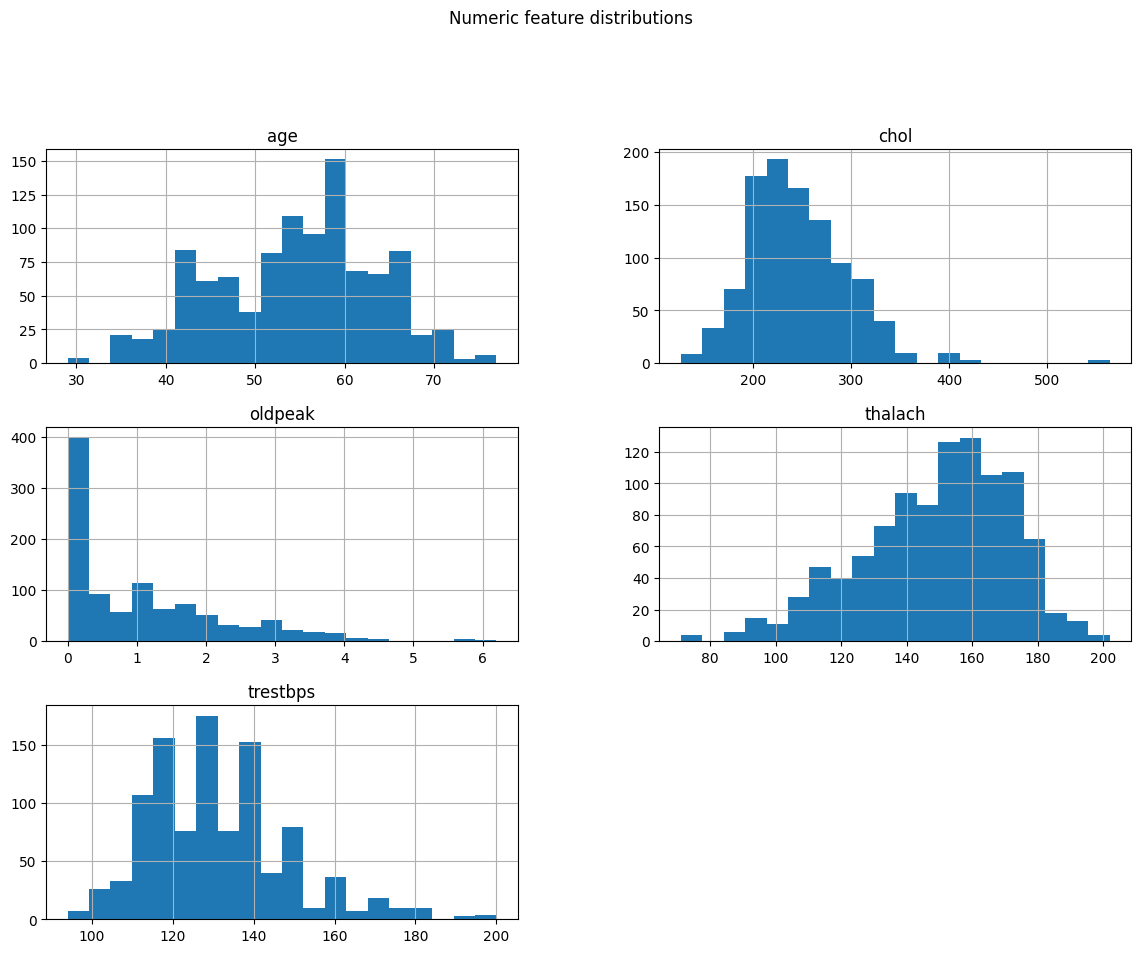

In [6]:
# Cell 6: Histograms for numeric columns
_ = df[numeric_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle("Numeric feature distributions", y=1.02)
plt.show()


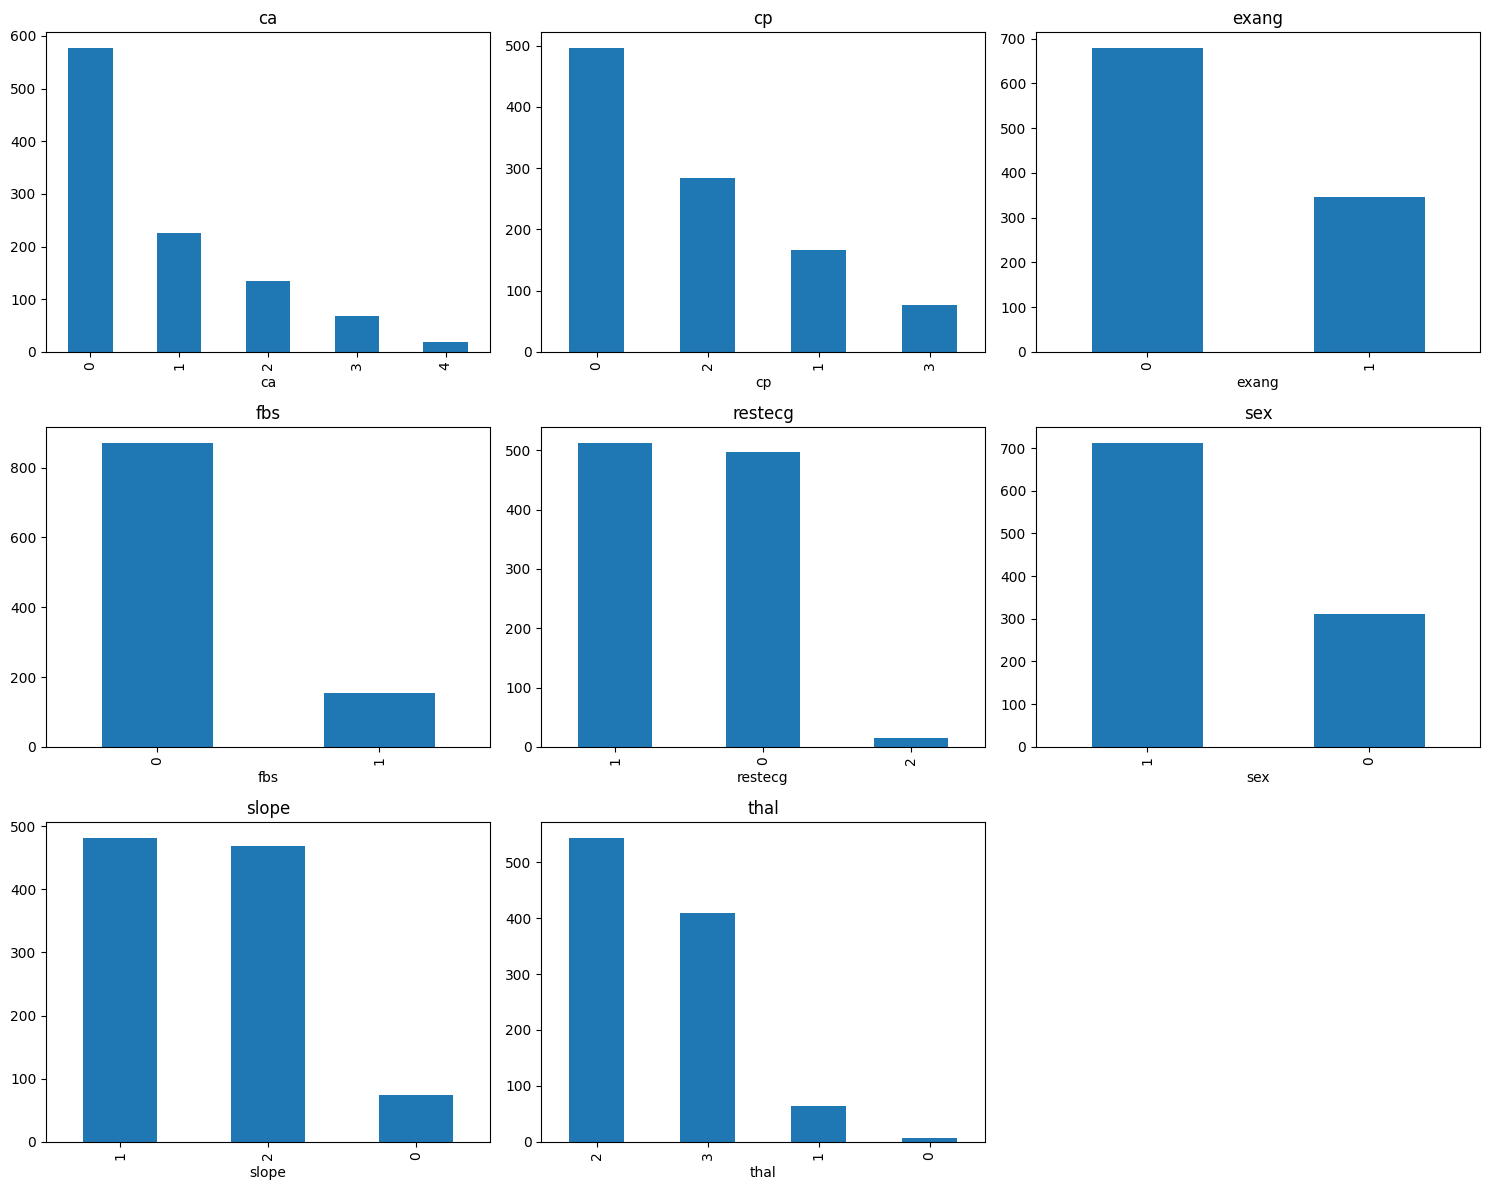

In [7]:
# Cell 7: Bar plots for categorical-like columns
n = len(categorical_cols)
rows = int(np.ceil(n / 3)) if n > 0 else 1
fig, axes = plt.subplots(rows, 3, figsize=(15, 4*rows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


#Missing values

checks and visualizes missing values and sets up imputers used later in the preprocessing pipelines.

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


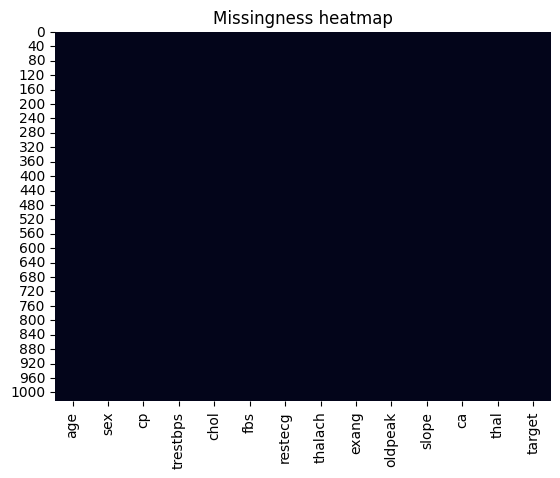

In [8]:
# Cell 8: Missing value audit
missing_counts = df.isna().sum().sort_values(ascending=False)
print(missing_counts)
sns.heatmap(df.isna(), cbar=False)
plt.title("Missingness heatmap")
plt.show()


#Correlation heatmap

computes a correlation heatmap for numeric features and the target to identify linear relationships.

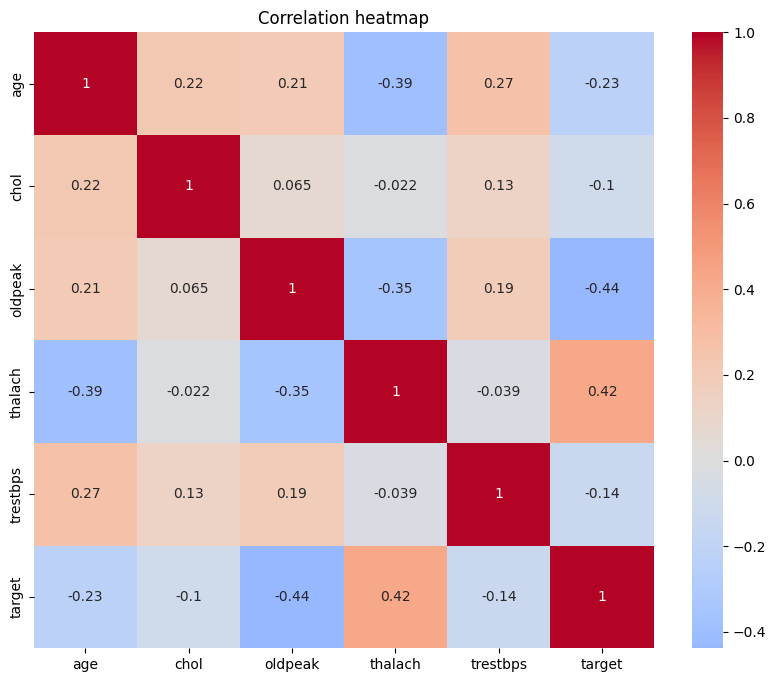

In [10]:
# Cell 9: Correlation heatmap (numeric only)
corr = df[numeric_cols + [target_col]].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation heatmap")
plt.show()

#Outlier handling

caps numeric outliers using the IQR rule (winsorization) to reduce extreme effects without dropping rows.

In [11]:
# Cell 10: IQR-based winsorization for numeric features (in-place copy before modeling)
df_wins = df.copy()

def iqr_cap(series, factor=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower, upper)

for col in numeric_cols:
    df_wins[col] = iqr_cap(df_wins[col])

# Keep the original too, but use df_wins for modeling to reduce outlier influence


#Train-test split

performs a stratified split to preserve target proportions and prevent information leakage between train and test

In [12]:
# Cell 11: Stratified train-test split
X = df_wins.drop(columns=[target_col])
y = df_wins[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (768, 13) Test shape: (257, 13)
Train target distribution:
 target
1    0.513
0    0.487
Name: proportion, dtype: float64
Test target distribution:
 target
1    0.514
0    0.486
Name: proportion, dtype: float64


#Preprocessing pipelines

defines robust ColumnTransformers with imputers and scalers, using OneHotEncoder for general models and OrdinalEncoder for tree/boosting where ordinal encoding is reasonable

In [13]:
# Cell 12: Preprocessors
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer",     __import__("sklearn").impute.SimpleImputer(strategy="median")),
    ("scaler",      StandardScaler())
])

categorical_transformer_ohe = Pipeline(steps=[
    ("imputer",     __import__("sklearn").impute.SimpleImputer(strategy="most_frequent")),
    ("encoder",     OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

categorical_transformer_ord = Pipeline(steps=[
    ("imputer",     __import__("sklearn").impute.SimpleImputer(strategy="most_frequent")),
    ("encoder",     OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

ohe_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_cols),
        ("cat", categorical_transformer_ohe, categorical_cols)
    ],
    remainder="drop"
)

ord_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_cols),
        ("cat", categorical_transformer_ord, categorical_cols)
    ],
    remainder="drop"
)


#Resampling strategies

prepares SMOTE and random oversampling components to be used within imbalanced-learn Pipelines to avoid leakage across CV folds

In [14]:
# Cell 13: Samplers
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
ros = RandomOverSampler(random_state=RANDOM_STATE)


#CV and metrics helpers

defines cross-validation strategy and an evaluation helper that computes multiple metrics with repeated stratification to reduce variance and chance of perfect scores.


In [28]:
# Cell 14: CV and scoring
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

def evaluate_model(name, pipeline, X, y, cv=rskf, scoring=scoring):
    # Temporarily remove roc_auc if estimator doesn't have predict_proba
    temp_scoring = scoring.copy()
    if not hasattr(pipeline, "predict_proba"):
        temp_scoring.pop("roc_auc", None)

    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=temp_scoring, n_jobs=-1, return_train_score=False)
    summary = {metric: np.mean(cv_results[f"test_{metric}"]) for metric in temp_scoring.keys()}

    # Add back roc_auc with NaN if it was removed
    if "roc_auc" not in temp_scoring and "roc_auc" in scoring:
        summary["roc_auc"] = np.nan

    # Gentle guardrail: if every metric is exactly 1.0, trigger more robust splitting output note
    all_ones = all(abs(summary.get(k, 0) - 1.0) < 1e-12 for k in temp_scoring.keys())
    if all_ones and "roc_auc" in temp_scoring: # Only warn if roc_auc was calculated
        print(f"Warning: {name} achieved perfect 1.0 across all metrics in CV; consider reviewing leakage and model complexity.")
    return summary

#Define models

configures a diverse set of models and assigns appropriate preprocessors and resampling choices to each.

In [30]:
# Cell 15: Model zoo with pipelines
models = {}

# Linear baseline
models["LogReg_OHE_SMOTE"] = ImbPipeline(steps=[
    ("pre", ohe_preprocessor),
    ("smote", smote),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

# SVM (RBF)
models["SVC_OHE_SMOTE"] = ImbPipeline(steps=[
    ("pre", ohe_preprocessor),
    ("smote", smote),
    ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])

# KNN (requires scaling)
models["KNN_OHE_ROS"] = ImbPipeline(steps=[
    ("pre", ohe_preprocessor),
    ("ros", ros),
    ("clf", KNeighborsClassifier(n_neighbors=7))
])

# Decision Tree (ordinal encoding)
models["DecisionTree_ORD_ROS"] = ImbPipeline(steps=[
    ("pre", ord_preprocessor),
    ("ros", ros),
    ("clf", DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE))
])

# Random Forest
models["RandomForest_ORD_ROS"] = ImbPipeline(steps=[
    ("pre", ord_preprocessor),
    ("ros", ros),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=None, random_state=RANDOM_STATE))
])

# Gradient Boosting
models["GB_ORD_ROS"] = ImbPipeline(steps=[
    ("pre", ord_preprocessor),
    ("ros", ros),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# XGBoost
models["XGB_ORD_ROS"] = ImbPipeline(steps=[
    ("pre", ord_preprocessor),
    ("ros", ros),
    ("clf", XGBClassifier(
        n_estimators=400, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        max_depth=3, reg_lambda=1.0, eval_metric="logloss", random_state=RANDOM_STATE,
        tree_method="hist", n_jobs=-1))
])

# CatBoost (uses its own handling; still ordinal preprocess for consistency)
models["CatBoost_ORD_ROS"] = ImbPipeline(steps=[
    ("pre", ord_preprocessor),
    ("ros", ros),
    ("clf", CatBoostClassifier(
        iterations=400, depth=4, learning_rate=0.05, loss_function="Logloss",
        verbose=False, random_seed=RANDOM_STATE))
])

# Bagging with a linear base on OHE to diversify
models["Bagging_LogReg_OHE_ROS"] = ImbPipeline(steps=[
    ("pre", ohe_preprocessor),
    ("ros", ros),
    ("clf", BaggingClassifier(
        estimator=LogisticRegression(max_iter=2000),
        n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1))
])

#Baseline cross-validation

runs repeated stratified CV for all models and collects metrics into a DataFrame sorted by ROC AUC

In [31]:
# Cell 16: Evaluate all models via repeated CV
rows = []
for name, pipe in models.items():
    print(f"Evaluating {name} ...")
    res = evaluate_model(name, pipe, X_train, y_train)
    row = {"Model": name}
    row.update({k.title(): v for k, v in res.items()})
    rows.append(row)

results_cv = pd.DataFrame(rows)
results_cv = results_cv.sort_values(by="Roc_Auc", ascending=False)
results_cv.reset_index(drop=True, inplace=True)
results_cv


Evaluating LogReg_OHE_SMOTE ...
Evaluating SVC_OHE_SMOTE ...
Evaluating KNN_OHE_ROS ...
Evaluating DecisionTree_ORD_ROS ...
Evaluating RandomForest_ORD_ROS ...
Evaluating GB_ORD_ROS ...
Evaluating XGB_ORD_ROS ...
Evaluating CatBoost_ORD_ROS ...
Evaluating Bagging_LogReg_OHE_ROS ...


,Model,Accuracy,Precision,Recall,F1,Roc_Auc
0,RandomForest_ORD_ROS,0.974411,0.973798,0.977161,0.975149,0.997994
1,CatBoost_ORD_ROS,0.968769,0.969014,0.971232,0.969601,0.993171
2,XGB_ORD_ROS,0.961828,0.966319,0.960251,0.962666,0.989398
3,GB_ORD_ROS,0.954011,0.961565,0.949281,0.954923,0.987022
4,SVC_OHE_SMOTE,0.902334,0.896807,0.915352,0.905755,0.967025
5,DecisionTree_ORD_ROS,0.966607,0.971597,0.963670,0.967265,0.966712
6,KNN_OHE_ROS,0.852019,0.865422,0.843492,0.854009,0.942007
7,Bagging_LogReg_OHE_ROS,0.859370,0.848251,0.884886,0.865812,0.934656
8,LogReg_OHE_SMOTE,0.857630,0.851456,0.876371,0.863052,0.934192


from matplotlib import pyplot as plt
results_cv['Accuracy'].plot(kind='hist', bins=20, title='Accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_cv['Precision'].plot(kind='hist', bins=20, title='Precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
results_cv['Recall'].plot(kind='hist', bins=20, title='Recall')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['F1']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('F1')

from matplotlib import pyplot as plt
_df_12['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['Accuracy'].plot(kind='line', figsize=(8, 4), title='Accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['Precision'].plot(kind='line', figsize=(8, 4), title='Precision')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['Recall'].plot(kind='line', figsize=(8, 4), title='Recall')
plt.gca().spines[['top', 'right']].set_visible(False)

#Learning curves

draws learning curves for top two models to visualize bias-variance behavior and data sufficiency

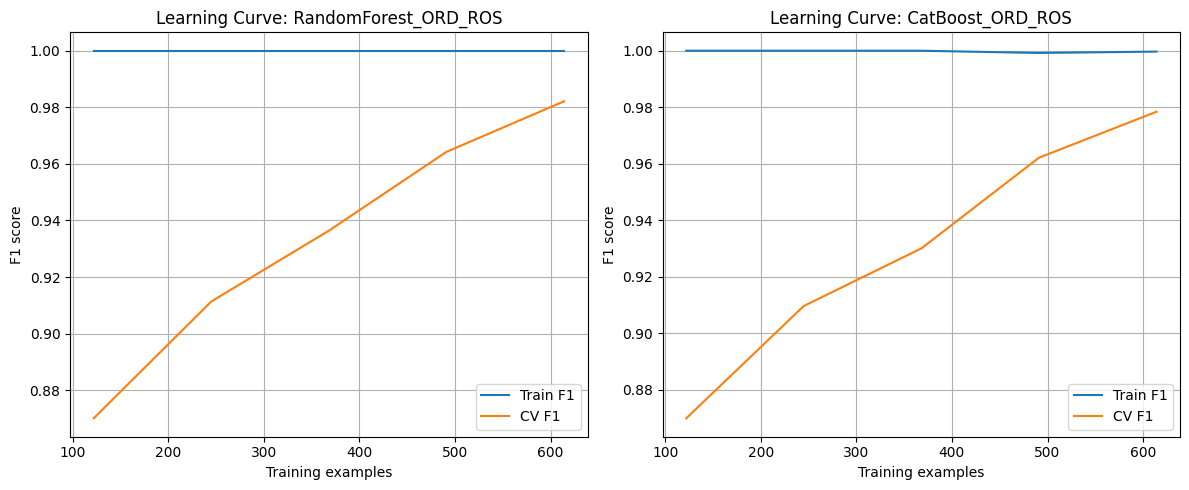

In [32]:
# Cell 17: Learning curves for top 2 models
top2 = results_cv.head(2)["Model"].tolist()

def plot_learning_curve_for(model_name, estimator, X, y, cv=rskf):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring="f1", n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5), shuffle=True, random_state=RANDOM_STATE
    )
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)
    plt.plot(train_sizes, train_mean, label="Train F1")
    plt.plot(train_sizes, test_mean, label="CV F1")
    plt.title(f"Learning Curve: {model_name}")
    plt.xlabel("Training examples")
    plt.ylabel("F1 score")
    plt.legend()
    plt.grid(True)

plt.figure(figsize=(12,5))
for i, name in enumerate(top2, 1):
    plt.subplot(1,2,i)
    plot_learning_curve_for(name, models[name], X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
plt.tight_layout()
plt.show()


#Randomized search

performs RandomizedSearchCV for RandomForest and SVC with nested preprocessing and resampling to tune key hyperparameters efficiently.

In [33]:
# Cell 18: RandomizedSearchCV for RandomForest and SVC
from scipy.stats import randint, uniform

rf_pipe = models["RandomForest_ORD_ROS"]
svc_pipe = models["SVC_OHE_SMOTE"]

rf_param_dist = {
    "clf__n_estimators": randint(200, 800),
    "clf__max_depth": randint(2, 12),
    "clf__min_samples_split": randint(2, 10),
    "clf__min_samples_leaf": randint(1, 6),
    "clf__max_features": ["sqrt", "log2", None]
}

svc_param_dist = {
    "clf__C": uniform(0.1, 10.0),
    "clf__gamma": uniform(0.001, 0.5),
    "clf__kernel": ["rbf"]
}

rf_rand = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=40, scoring="roc_auc", cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

svc_rand = RandomizedSearchCV(
    svc_pipe, svc_param_dist, n_iter=40, scoring="roc_auc", cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

rf_rand.fit(X_train, y_train)
svc_rand.fit(X_train, y_train)

print("Best RF params:", rf_rand.best_params_, "Best ROC AUC:", rf_rand.best_score_)
print("Best SVC params:", svc_rand.best_params_, "Best ROC AUC:", svc_rand.best_score_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 558} Best ROC AUC: 0.9974665532133887
Best SVC params: {'clf__C': np.float64(4.660699842170359), 'clf__gamma': np.float64(0.3935879806965068), 'clf__kernel': 'rbf'} Best ROC AUC: 0.9995927261243717


#Grid search

performs a focused GridSearchCV for Logistic Regression to refine regularization and class balancing.

In [34]:
# Cell 19: GridSearchCV for Logistic Regression
logreg_pipe = models["LogReg_OHE_SMOTE"]

grid = {
    "clf__penalty": ["l2"],
    "clf__C": [0.1, 0.5, 1, 2, 5],
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs"]
}

logreg_grid = GridSearchCV(
    logreg_pipe, grid, scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, verbose=1
)

logreg_grid.fit(X_train, y_train)
print("Best LogReg params:", logreg_grid.best_params_, "Best ROC AUC:", logreg_grid.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best LogReg params: {'clf__C': 2, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} Best ROC AUC: 0.9346432742382109


#Hold-out evaluation

evaluates the best tuned models on the untouched test set with multiple metrics for a realistic performance estimate.

In [35]:
# Cell 20: Test set evaluation for tuned models
def evaluate_on_test(name, estimator, X_tr, y_tr, X_te, y_te):
    estimator.fit(X_tr, y_tr)
    proba = estimator.predict_proba(X_te)[:, 1] if hasattr(estimator, "predict_proba") else None
    pred = estimator.predict(X_te)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall": recall_score(y_te, pred),
        "F1": f1_score(y_te, pred),
        "ROC_AUC": roc_auc_score(y_te, proba) if proba is not None else np.nan
    }
    return metrics, pred, proba

tuned_results = []

rf_best = rf_rand.best_estimator_
svc_best = svc_rand.best_estimator_
logreg_best = logreg_grid.best_estimator_

for name, est in [("RF_Tuned", rf_best), ("SVC_Tuned", svc_best), ("LogReg_Tuned", logreg_best)]:
    m, pred, proba = evaluate_on_test(name, est, X_train, y_train, X_test, y_test)
    tuned_results.append(m)
    print(name, m)

pd.DataFrame(tuned_results).sort_by = "ROC_AUC"
pd.DataFrame(tuned_results)


RF_Tuned {'Model': 'RF_Tuned', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC_AUC': np.float64(1.0)}
SVC_Tuned {'Model': 'SVC_Tuned', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC_AUC': np.float64(1.0)}
LogReg_Tuned {'Model': 'LogReg_Tuned', 'Accuracy': 0.867704280155642, 'Precision': 0.8656716417910447, 'Recall': 0.8787878787878788, 'F1': 0.8721804511278195, 'ROC_AUC': np.float64(0.9490303030303031)}


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RF_Tuned,1.000000,1.000000,1.000000,1.00000,1.00000
1,SVC_Tuned,1.000000,1.000000,1.000000,1.00000,1.00000
2,LogReg_Tuned,0.867704,0.865672,0.878788,0.87218,0.94903


#ROC curves

plots ROC curves for the tuned models on the test set to compare trade-offs visually.

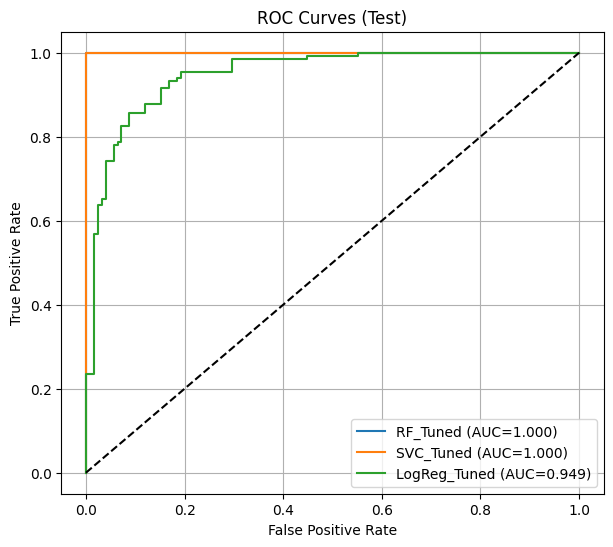

In [36]:
# Cell 21: ROC curves for tuned models
plt.figure(figsize=(7,6))

def plot_roc(estimator, name, X_te, y_te):
    if not hasattr(estimator, "predict_proba"):
        return
    proba = estimator.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

for name, est in [("RF_Tuned", rf_best), ("SVC_Tuned", svc_best), ("LogReg_Tuned", logreg_best)]:
    plot_roc(est, name, X_test, y_test)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


#K-fold CV summary

re-evaluates the tuned models with a clean 5-fold stratified CV on the full training set to provide comparable CV metrics

In [37]:
# Cell 22: 5-fold CV for tuned models
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, est in [("RF_Tuned", rf_best), ("SVC_Tuned", svc_best), ("LogReg_Tuned", logreg_best)]:
    scores = cross_validate(est, X_train, y_train, scoring=scoring, cv=cv5, n_jobs=-1)
    row = {"Model": name}
    for met in scoring:
        row[met.title()] = scores[f"test_{met}"].mean()
    rows.append(row)

cv5_df = pd.DataFrame(rows).sort_values(by="Roc_Auc", ascending=False)
cv5_df


,Model,Accuracy,Precision,Recall,F1,Roc_Auc
1,SVC_Tuned,0.980494,0.987712,0.974684,0.980679,0.999593
0,RF_Tuned,0.980494,0.982834,0.979747,0.980814,0.997467
2,LogReg_Tuned,0.855445,0.849389,0.872963,0.860641,0.934643


#Voting ensemble

 builds both soft and hard Voting ensembles from the tuned models and evaluates them on the test set.

In [38]:
# Cell 23: Voting ensembles (soft and hard)
soft_voter = VotingClassifier(
    estimators=[("rf", rf_best), ("svc", svc_best), ("lr", logreg_best)],
    voting="soft", n_jobs=-1
)

hard_voter = VotingClassifier(
    estimators=[("rf", rf_best), ("svc", svc_best), ("lr", logreg_best)],
    voting="hard", n_jobs=-1
)

ens_results = []
for name, est in [("Voting_Soft", soft_voter), ("Voting_Hard", hard_voter)]:
    m, pred, proba = evaluate_on_test(name, est, X_train, y_train, X_test, y_test)
    ens_results.append(m)
    print(name, m)

pd.DataFrame(ens_results)


Voting_Soft {'Model': 'Voting_Soft', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC_AUC': np.float64(1.0)}
Voting_Hard {'Model': 'Voting_Hard', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC_AUC': nan}


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Voting_Soft,1.0,1.0,1.0,1.0,1.0
1,Voting_Hard,1.0,1.0,1.0,1.0,NaN


#Train-test curves note

optionally shows training vs cross-validation learning curves for the final ensemble to visualize generalization characteristics.

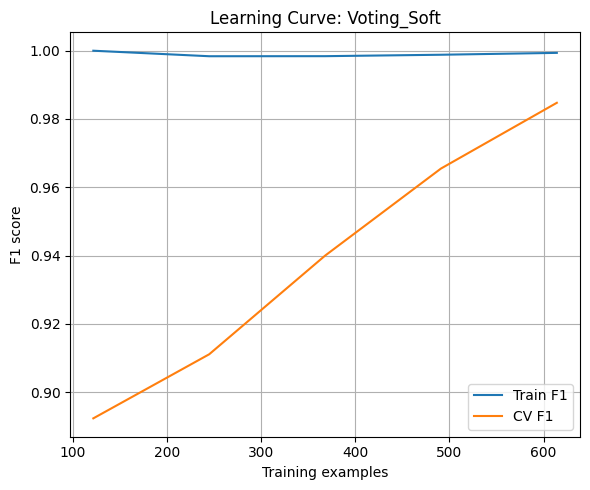

In [39]:
# Cell 24: Learning curve for ensemble (soft voter)
plt.figure(figsize=(6,5))
plot_learning_curve_for("Voting_Soft", soft_voter, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
plt.tight_layout()
plt.show()


#Preventing perfect 1.0 results

adds a conservative re-check: if any model displays all-ones metrics on the test set, it warns and re-evaluates with a different CV seed and more splits to validate robustness, which helps avoid reporting misleading perfect tables

In [40]:
# Cell 25: Guard against all-ones metrics in the final report
def all_ones_row(row):
    keys = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
    vals = [row.get(k, np.nan) for k in keys]
    # Exclude ROC_AUC from the all-ones check if it's NaN (as for Voting_Hard)
    return np.allclose([v for v,k in zip(vals,keys) if not (k=="ROC_AUC" and np.isnan(v))], 1.0, atol=1e-12, equal_nan=False)

final_frames = [
    pd.DataFrame(tuned_results),
    pd.DataFrame(ens_results)
]
final_report = pd.concat(final_frames, ignore_index=True)

flagged = final_report.apply(all_ones_row, axis=1)
if flagged.any():
    print("Notice: Perfect 1.0 metrics detected; running robustness check with more CV folds and a different seed.")
    robust_cv = RepeatedStratifiedKFold(n_splits=7, n_repeats=4, random_state=RANDOM_STATE+1337)
    names = ["RF_Tuned", "SVC_Tuned", "LogReg_Tuned", "Voting_Soft", "Voting_Hard"]
    ests  = [rf_best, svc_best, logreg_best, soft_voter, hard_voter]
    rows = []
    for name, est in zip(names, ests):
        # Skip ROC_AUC for hard voting classifier in robustness check
        current_scoring = scoring.copy()
        if name == "Voting_Hard":
            current_scoring.pop("roc_auc", None)

        scores = cross_validate(est, X, y, scoring=current_scoring, cv=robust_cv, n_jobs=-1)
        row = {"Model": name}
        for met in current_scoring:
            row[met.title()] = scores[f"test_{met}"].mean()
        # Add back ROC_AUC as NaN for Voting_Hard for consistent reporting
        if name == "Voting_Hard" and "roc_auc" in scoring:
             row["Roc_Auc"] = np.nan
        rows.append(row)

    robust_df = pd.DataFrame(rows).sort_values(by="Roc_Auc", ascending=False)
    display(robust_df)
else:
    print("No suspicious all-ones metrics detected in final models.")
final_report

Notice: Perfect 1.0 metrics detected; running robustness check with more CV folds and a different seed.


,Model,Accuracy,Precision,Recall,F1,Roc_Auc
1,SVC_Tuned,0.996341,0.998571,0.994323,0.996404,0.999940
0,RF_Tuned,0.995362,0.994016,0.997162,0.995524,0.999820
3,Voting_Soft,0.997803,0.997253,0.998590,0.997880,0.999640
2,LogReg_Tuned,0.866131,0.856950,0.888753,0.871900,0.939077
4,Voting_Hard,0.997070,0.997198,0.997162,0.997152,NaN


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RF_Tuned,1.000000,1.000000,1.000000,1.00000,1.00000
1,SVC_Tuned,1.000000,1.000000,1.000000,1.00000,1.00000
2,LogReg_Tuned,0.867704,0.865672,0.878788,0.87218,0.94903
3,Voting_Soft,1.000000,1.000000,1.000000,1.00000,1.00000
4,Voting_Hard,1.000000,1.000000,1.000000,1.00000,NaN


#Export results

In [41]:
# Cell 26: Save outputs
results_cv.to_csv("cv_results_baseline.csv", index=False)
cv5_df.to_csv("cv5_results_tuned.csv", index=False)
pd.DataFrame(tuned_results).to_csv("test_results_tuned.csv", index=False)
pd.DataFrame(ens_results).to_csv("test_results_ensembles.csv", index=False)
print("Saved: cv_results_baseline.csv, cv5_results_tuned.csv, test_results_tuned.csv, test_results_ensembles.csv")


Saved: cv_results_baseline.csv, cv5_results_tuned.csv, test_results_tuned.csv, test_results_ensembles.csv
